# RetinaNet Object Detection — PPE Dataset (5 Classes)

Complete PyTorch/Torchvision notebook for the 5-class PPE dataset.

Classes: `helmet`, `no_helmet`, `no_vest`, `person`, `vest`

Expected COCO-converted structure:
```text
dataset/
├── train/images/ + annotations.json
├── valid/images/ + annotations.json
└── test/images/ + annotations.json
```

The COCO category IDs are 0–4. PyTorch detection labels use 0 for background, so object labels are converted to 1–5.

In [ ]:
!pip install -q pycocotools

In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models import ResNet50_Weights

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda


In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

0.0 GB allocated
0.0 GB reserved


## 3. Dataset paths

Change `YOUR_DATASET` to your Kaggle dataset folder name.

In [ ]:
DATASET_DIR = "/kaggle/input/datasets/haniamamdouh/helmet-vest-dataset"

TRAIN_IMAGES = os.path.join(DATASET_DIR, "train", "images")
TRAIN_JSON   = os.path.join(DATASET_DIR, "train", "annotations.json")

VALID_IMAGES = os.path.join(DATASET_DIR, "valid", "images")
VALID_JSON   = os.path.join(DATASET_DIR, "valid", "annotations.json")

TEST_IMAGES  = os.path.join(DATASET_DIR, "test", "images")
TEST_JSON    = os.path.join(DATASET_DIR, "test", "annotations.json")

print(TRAIN_IMAGES)
print(VALID_IMAGES)
print(TEST_IMAGES)

/kaggle/input/datasets/haniamamdouh/helmet-vest-dataset/train/images
/kaggle/input/datasets/haniamamdouh/helmet-vest-dataset/valid/images
/kaggle/input/datasets/haniamamdouh/helmet-vest-dataset/test/images


In [ ]:
CLASSES = ["helmet", "no_helmet", "no_vest", "person", "vest"]
NUM_CLASSES = len(CLASSES)

print("Number of classes:", NUM_CLASSES)
print(CLASSES)

Number of classes: 5
['helmet', 'no_helmet', 'no_vest', 'person', 'vest']


## 5. Verify COCO category IDs

In [ ]:
with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

print(test_coco["categories"])

[{'id': 0, 'name': 'helmet', 'supercategory': 'PPE'}, {'id': 1, 'name': 'no_helmet', 'supercategory': 'PPE'}, {'id': 2, 'name': 'no_vest', 'supercategory': 'PPE'}, {'id': 3, 'name': 'person', 'supercategory': 'PPE'}, {'id': 4, 'name': 'vest', 'supercategory': 'PPE'}]


## 6. PyTorch Dataset

COCO boxes are `[x, y, width, height]`. RetinaNet expects `[x1, y1, x2, y2]`.

In [ ]:
class PPEDataset(Dataset):

    def __init__(self, images_dir, annotation_file):
        self.images_dir = images_dir

        with open(annotation_file, "r") as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations_by_image = {}

        for ann in coco["annotations"]:
            image_id = ann["image_id"]
            self.annotations_by_image.setdefault(image_id, []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_info = self.images[idx]
        image_id = image_info["id"]
        image_path = os.path.join(self.images_dir, image_info["file_name"])

        image = Image.open(image_path).convert("RGB")
        image = TF.to_tensor(image)

        boxes = []
        labels = []

        for ann in self.annotations_by_image.get(image_id, []):
            x, y, w, h = ann["bbox"]
            x1, y1 = x, y
            x2, y2 = x + w, y + h

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])

            # COCO IDs 0–4 -> PyTorch IDs 1–5
            labels.append(ann["category_id"] + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id])
        }

        return image, target

In [ ]:
train_dataset = PPEDataset(TRAIN_IMAGES, TRAIN_JSON)
valid_dataset = PPEDataset(VALID_IMAGES, VALID_JSON)
test_dataset  = PPEDataset(TEST_IMAGES, TEST_JSON)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 3248
Valid: 406
Test : 406


In [ ]:
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"])
print("Image ID:", target["image_id"])

Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([7, 4])
Labels: tensor([1, 1, 3, 3, 4, 4, 4])
Image ID: tensor([1])


## 9. Visualize ground truth

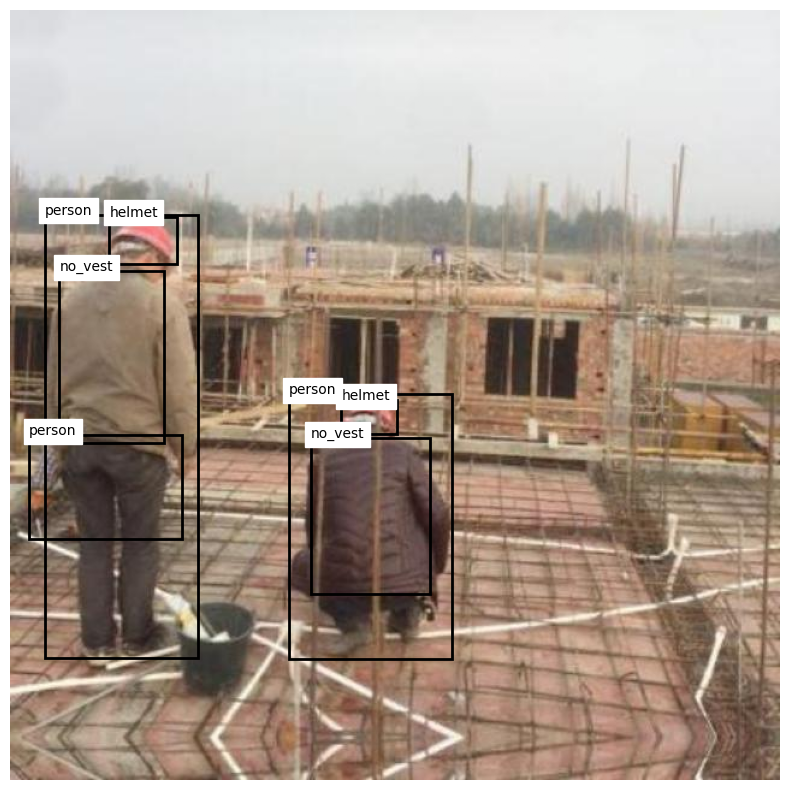

In [ ]:
def show_sample(dataset, index=0):
    image, target = dataset[index]
    image_np = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(image_np)
    ax = plt.gca()

    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()

        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, linewidth=2
        )
        ax.add_patch(rect)

        class_name = CLASSES[label.item() - 1]
        ax.text(
            x1, y1, class_name,
            fontsize=10, backgroundcolor="white"
        )

    plt.axis("off")
    plt.show()

show_sample(train_dataset, 0)

## 10. DataLoaders

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


## 11. Create RetinaNet

In [ ]:
model = retinanet_resnet50_fpn(
    weights=None,
    weights_backbone=ResNet50_Weights.DEFAULT,
    num_classes=NUM_CLASSES + 1
)

model = model.to(device)
print("RetinaNet created.")

RetinaNet created.


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

## 13. Training function

In [ ]:
def train_one_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [image.to(device) for image in images]

        targets = [
            {key: value.to(device) for key, value in target.items()}
            for target in targets
        ]

        loss_dict = model(images, targets)
        loss = sum(loss_value for loss_value in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            print(
                f"Batch [{batch_idx + 1}/{len(data_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    return total_loss / len(data_loader)

## 14. Validation loss

In [ ]:
def validation_loss(model, data_loader, device):
    # Torchvision detection models return losses in train mode.
    model.train()
    total_loss = 0.0

    with torch.no_grad():
        for images, targets in data_loader:
            images = [image.to(device) for image in images]

            targets = [
                {key: value.to(device) for key, value in target.items()}
                for target in targets
            ]

            loss_dict = model(images, targets)
            loss = sum(loss_value for loss_value in loss_dict.values())
            total_loss += loss.item()

    return total_loss / len(data_loader)

## 15. Train RetinaNet

In [ ]:
NUM_EPOCHS = 5

train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    print(f"\n========== Epoch {epoch + 1}/{NUM_EPOCHS} ==========")
    start_time = time.time()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, device
    )

    val_loss = validation_loss(
        model, valid_loader, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Time: {time.time() - start_time:.1f} seconds")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "retinanet_ppe_best.pth")
        print("Best model saved.")


========== Epoch 1/10 ==========
Batch [20/3248] Loss: 1.7086
Batch [40/3248] Loss: 1.7088
Batch [60/3248] Loss: 1.5435
Batch [80/3248] Loss: 1.4654
Batch [100/3248] Loss: 1.6214
Batch [120/3248] Loss: 1.7394
Batch [140/3248] Loss: 1.3553
Batch [160/3248] Loss: 1.5199
Batch [180/3248] Loss: 0.9818
Batch [200/3248] Loss: 1.2991
Batch [220/3248] Loss: 1.6888
Batch [240/3248] Loss: 1.6403
Batch [260/3248] Loss: 1.1030
Batch [280/3248] Loss: 1.2171
Batch [300/3248] Loss: 1.0769
Batch [320/3248] Loss: 1.3103
Batch [340/3248] Loss: 1.3070
Batch [360/3248] Loss: 1.0414
Batch [380/3248] Loss: 1.0473
Batch [400/3248] Loss: 1.4619
Batch [420/3248] Loss: 1.2841
Batch [440/3248] Loss: 1.2099
Batch [460/3248] Loss: 1.0686
Batch [480/3248] Loss: 1.0527
Batch [500/3248] Loss: 0.9075
Batch [520/3248] Loss: 0.8112
Batch [540/3248] Loss: 1.0179
Batch [560/3248] Loss: 1.1977
Batch [580/3248] Loss: 1.5252
Batch [600/3248] Loss: 0.9947
Batch [620/3248] Loss: 1.3078
Batch [640/3248] Loss: 1.5159
Batch [660

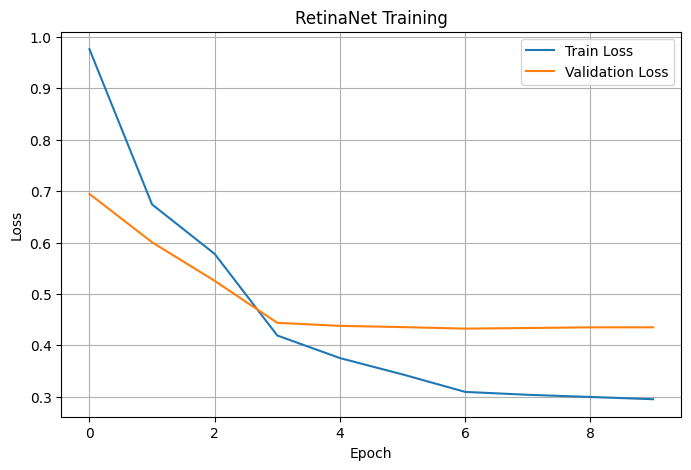

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RetinaNet Training")
plt.legend()
plt.grid()
plt.show()

## 17. Load best model

In [ ]:
model.load_state_dict(
    torch.load("retinanet_ppe_best.pth", map_location=device)
)
model = model.to(device)
print("Best model loaded.")

Best model loaded.


## 18. Prediction on a test batch

In [22]:
model.eval()

images, targets = next(iter(test_loader))
images_gpu = [image.to(device) for image in images]

with torch.no_grad():
    predictions = model(images_gpu)

print("Prediction keys:", predictions[0].keys())
print("Boxes:", predictions[0]["boxes"].shape)
print("Scores:", predictions[0]["scores"].shape)
print("Labels:", predictions[0]["labels"].shape)

Prediction keys: dict_keys(['boxes', 'scores', 'labels'])
Boxes: torch.Size([57, 4])
Scores: torch.Size([57])
Labels: torch.Size([57])


## 19. Visualize predictions

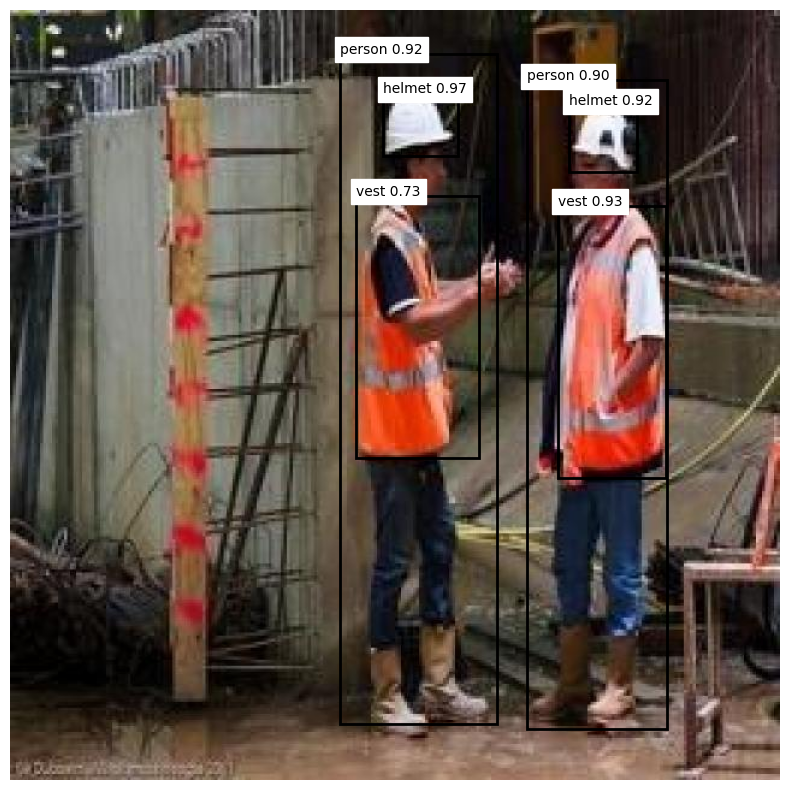

In [23]:
def show_prediction(image, prediction, score_threshold=0.5):
    image_np = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(image_np)
    ax = plt.gca()

    boxes = prediction["boxes"].cpu()
    scores = prediction["scores"].cpu()
    labels = prediction["labels"].cpu()

    for box, score, label in zip(boxes, scores, labels):
        if score < score_threshold:
            continue

        x1, y1, x2, y2 = box.tolist()

        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, linewidth=2
        )
        ax.add_patch(rect)

        class_name = CLASSES[label.item() - 1]
        ax.text(
            x1, y1, f"{class_name} {score:.2f}",
            fontsize=10, backgroundcolor="white"
        )

    plt.axis("off")
    plt.show()

for i in range(min(4, len(images))):
    show_prediction(images[i], predictions[i], score_threshold=0.5)

## 20. Prediction on a new image

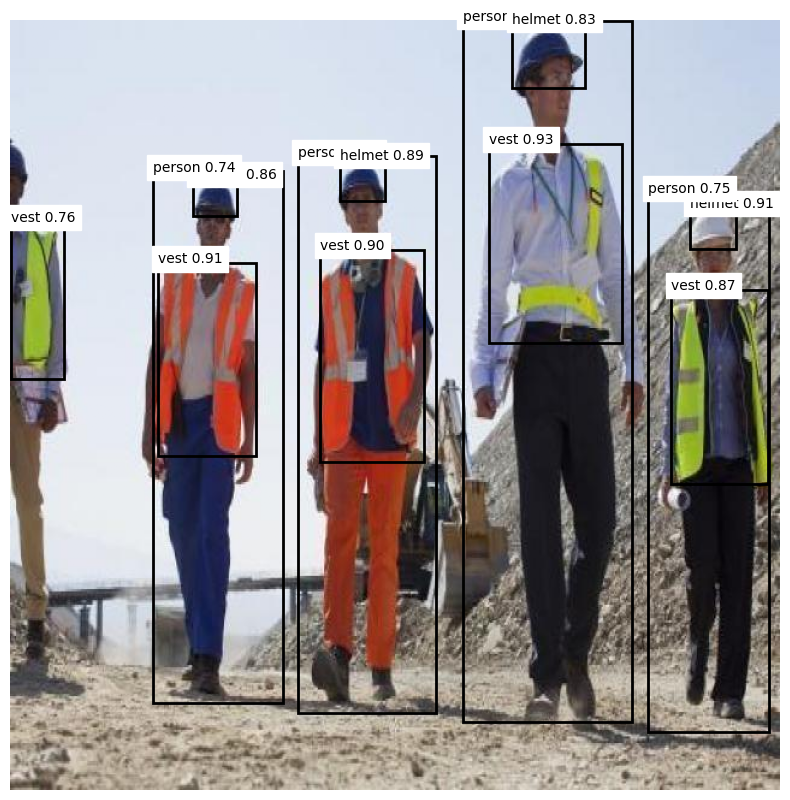

In [24]:
NEW_IMAGE = "/kaggle/input/datasets/haniamamdouh/helmet-vest-dataset/test/images/000010_jpg.rf.364564a48732cc7d3689f88cd1281a5b.jpg"

image_pil = Image.open(NEW_IMAGE).convert("RGB")
image_tensor = TF.to_tensor(image_pil).to(device)

model.eval()

with torch.no_grad():
    prediction = model([image_tensor])[0]

show_prediction(
    image_tensor.cpu(),
    prediction,
    score_threshold=0.5
)

## 21. Generate COCO-format predictions for the complete test set

In [25]:
model.eval()
coco_predictions = []

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(test_loader):
        images_gpu = [image.to(device) for image in images]
        predictions = model(images_gpu)

        for target, prediction in zip(targets, predictions):
            image_id = int(target["image_id"].item())

            boxes = prediction["boxes"].cpu().numpy()
            scores = prediction["scores"].cpu().numpy()
            labels = prediction["labels"].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box

                coco_predictions.append({
                    "image_id": image_id,
                    "category_id": int(label) - 1,
                    "bbox": [
                        float(x1),
                        float(y1),
                        float(x2 - x1),
                        float(y2 - y1)
                    ],
                    "score": float(score)
                })

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {(batch_idx + 1) * BATCH_SIZE} images")

print("Total detections:", len(coco_predictions))

Processed 10 images
Processed 20 images
Processed 30 images
Processed 40 images
Processed 50 images
Processed 60 images
Processed 70 images
Processed 80 images
Processed 90 images
Processed 100 images
Processed 110 images
Processed 120 images
Processed 130 images
Processed 140 images
Processed 150 images
Processed 160 images
Processed 170 images
Processed 180 images
Processed 190 images
Processed 200 images
Processed 210 images
Processed 220 images
Processed 230 images
Processed 240 images
Processed 250 images
Processed 260 images
Processed 270 images
Processed 280 images
Processed 290 images
Processed 300 images
Processed 310 images
Processed 320 images
Processed 330 images
Processed 340 images
Processed 350 images
Processed 360 images
Processed 370 images
Processed 380 images
Processed 390 images
Processed 400 images
Total detections: 27760


## 22. COCO evaluation — mAP@50 and mAP@50:95

In [26]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(TEST_JSON)
coco_dt = coco_gt.loadRes(coco_predictions)

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.21s).
Accumulating evaluation results...
DONE (t=0.40s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.477
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.811
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.505
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.176
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.500
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.563
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.318
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.551
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [27]:
map_50_95 = coco_eval.stats[0]
map_50 = coco_eval.stats[1]
map_75 = coco_eval.stats[2]

print(f"mAP@50:95 = {map_50_95:.4f}")
print(f"mAP@50    = {map_50:.4f}")
print(f"AP@75     = {map_75:.4f}")

mAP@50:95 = 0.4766
mAP@50    = 0.8109
AP@75     = 0.5049


## 24. Per-class AP

In [28]:
precision = coco_eval.eval["precision"]

for class_idx, class_name in enumerate(CLASSES):
    class_precision = precision[:, :, class_idx, 0, 2]
    class_precision = class_precision[class_precision > -1]

    ap = 0.0 if len(class_precision) == 0 else np.mean(class_precision)

    print(f"{class_name:12s}: AP = {ap:.4f}")

helmet      : AP = 0.4677
no_helmet   : AP = 0.4036
no_vest     : AP = 0.4137
person      : AP = 0.5452
vest        : AP = 0.5528


## 25. Inference time and FPS

In [29]:
model.eval()
times = []

for images, targets in test_loader:
    images_gpu = [image.to(device) for image in images]

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        _ = model(images_gpu)

    if device.type == "cuda":
        torch.cuda.synchronize()

    end = time.time()

    times.append((end - start) / len(images_gpu))

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Average inference time: {avg_time * 1000:.2f} ms/image")
print(f"FPS: {fps:.2f}")

Average inference time: 85.80 ms/image
FPS: 11.66


## 26. Model size / parameters

In [30]:
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 32,251,674
Trainable parameters: 32,029,274


## 27. Comparison table

In [31]:
results = pd.DataFrame({
    "Model": ["YOLOv8n", "YOLO11n", "RetinaNet"],
    "mAP@50": [None, None, map_50],
    "mAP@50:95": [None, None, map_50_95],
    "Inference Time (ms)": [None, None, avg_time * 1000],
    "FPS": [None, None, fps]
})

results

,Model,mAP@50,mAP@50:95,Inference Time (ms),FPS
0,YOLOv8n,NaN,NaN,NaN,NaN
1,YOLO11n,NaN,NaN,NaN,NaN
2,RetinaNet,0.810933,0.476595,85.796472,11.655491


## Notes

- RetinaNet uses ResNet-50 + FPN.
- The ResNet-50 backbone uses ImageNet pretrained weights.
- There are 5 PPE object classes plus background.
- COCO labels 0–4 are converted to PyTorch labels 1–5.
- COCO boxes `[x,y,w,h]` are converted to `[x1,y1,x2,y2]` for RetinaNet.
- Predictions are converted back to COCO format for `COCOeval`.
- Main detection metrics: mAP@50 and mAP@50:95.
- Inference time/FPS can be used when comparing RetinaNet with YOLOv8n and YOLO11n.